# Hurricane Milton Wind and SSH Figure


This notebook loads L4 wind, L3 along-track SSH, and L3 SWOT over the Gulf of Mexico for selected dates during Hurricane Miltion, then generates the multi-panel figure with the hurricane track and eye markers.

In [1]:
from pathlib import Path

from ocean_taco import CORE_DATASET_REVISION, CatalogConfig, GeoBox
from ocean_taco.retrieve import load_bbox_nc, load_hf_dataset

CACHE_ROOT = Path("/tmp/oceantaco-tutorial-cache") / "hurricane-milton"
CATALOG_CONFIG = CatalogConfig(cache_dir=CACHE_ROOT)
BOX = GeoBox(-100.0, -75.0, 15.0, 32.0)
DATE = "2024-10-09"
INCLUDE_DENSE_SWOT = False  # opt in only when the large regional source is appropriate
TOKENS = ("l4_wind", "l3_ssh") + (("l3_swot",) if INCLUDE_DENSE_SWOT else ())
OUTPUT_PATH = CACHE_ROOT / "hurricane_milton.png"

CACHE_ROOT.mkdir(parents=True, exist_ok=True)
print(f"Pinned revision: {CORE_DATASET_REVISION}")
print(f"Cache: {CACHE_ROOT}")
print(f"Date: {DATE}; products: {', '.join(TOKENS)}")


Pinned revision: 878befc437a49cbf584353efc7346ebe705e743c
Cache: /tmp/oceantaco-tutorial-cache/hurricane-milton
Date: 2024-10-09; products: l4_wind, l3_ssh


In [2]:
catalog = load_hf_dataset(CATALOG_CONFIG)
data = {}
for token in TOKENS:
    dataset = load_bbox_nc(catalog, DATE, BOX, token, config=CATALOG_CONFIG)
    if dataset is None:
        print(f"{token}: no matching data")
    else:
        data[token] = dataset
        print(f"{token}: {dict(dataset.sizes)}")

if not data:
    raise RuntimeError("No Hurricane Milton products were retrieved from the pinned catalog.")


l4_wind: {'time': 1, 'lat': 136, 'lon': 200}


l3_ssh: {'time': 1, 'track': 7, 'lat': 270, 'lon': 281}


Saved /tmp/oceantaco-tutorial-cache/hurricane-milton/hurricane_milton.png


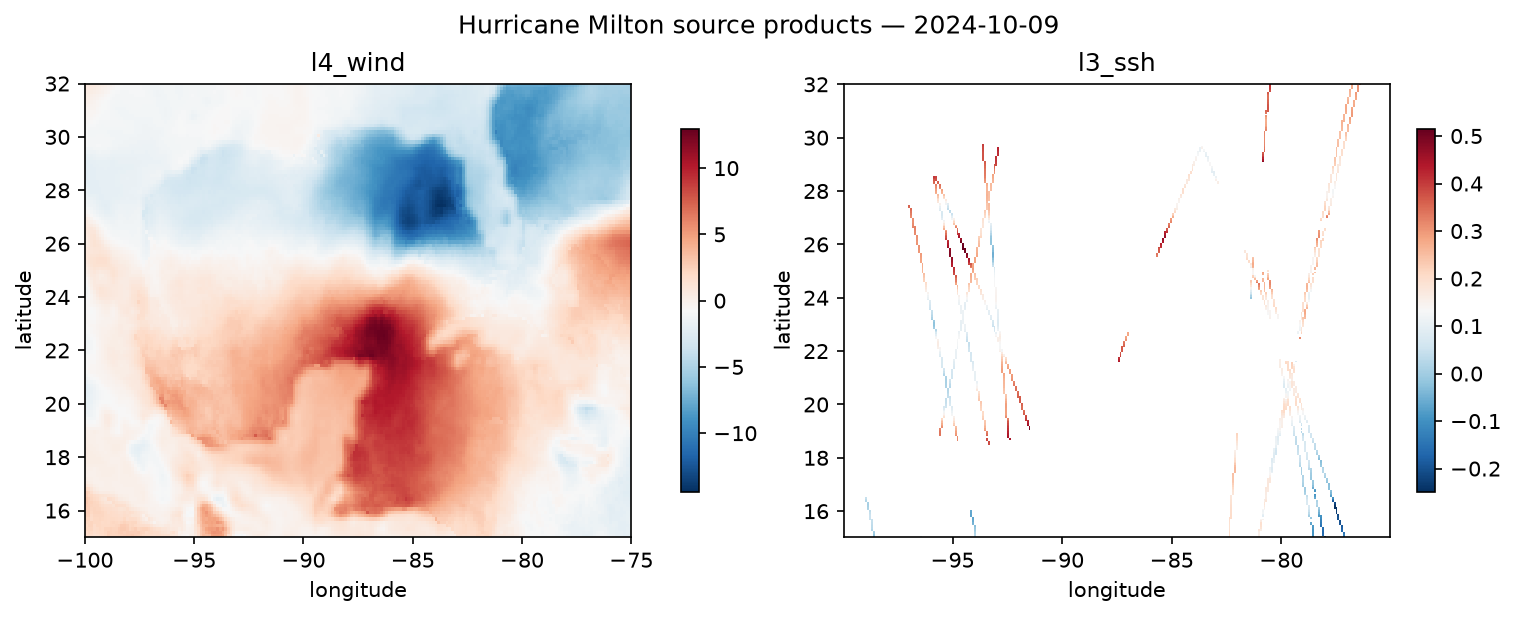

In [3]:
import matplotlib.pyplot as plt
from IPython.display import Image, display

VARIABLES = {
    "l4_wind": "eastward_wind",
    "l3_ssh": "sla_filtered",
    "l3_swot": "ssha_filtered",
}

def surface_field(dataset, variable):
    field = dataset[variable]
    for dimension in ("time", "depth"):
        if dimension in field.dims:
            field = field.isel({dimension: 0})
    return field.squeeze()

fig, axes = plt.subplots(1, len(data), figsize=(5 * len(data), 4), constrained_layout=True)
if len(data) == 1:
    axes = [axes]
for axis, (token, dataset) in zip(axes, data.items()):
    field = surface_field(dataset, VARIABLES[token])
    image = axis.pcolormesh(field["lon"], field["lat"], field, shading="auto", cmap="RdBu_r")
    axis.set(title=token, xlabel="longitude", ylabel="latitude")
    fig.colorbar(image, ax=axis, shrink=0.8)
fig.suptitle(f"Hurricane Milton source products — {DATE}")
fig.savefig(OUTPUT_PATH, dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"Saved {OUTPUT_PATH}")
display(Image(filename=OUTPUT_PATH))
